<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-de-medios-continuos/MCON_Tarea4_Sismologia_interior_planetario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica De Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 4</center></b><h2>
<h3><b><center>Overshooting planetario y sismología</center></b><h3>
<h5><center><b>Asignada</b>: 18 de Abril de 2024</center><h5>
<h5><center><b>Entrega</b>: 30 de Abril de 2024</center><h5>
</p>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>: 8/5/24
<hr/>

In [ ]:
!pip install -q spiceypy # datos planetarios
!pip install -Uq rockhound # modelo PREM

In [ ]:
import numpy as np
import spiceypy as spy
import rockhound as rh
import scipy.constants as cts
import matplotlib.pyplot as plt
import astropy.constants as astrocts

from tqdm import tqdm
from scipy.optimize import curve_fit # ajuste de curvas
from scipy.signal import argrelextrema as extrem # extremos relativos
from scipy.integrate import solve_ivp # solucion de sistemas ED

plt.style.use('seaborn-v0_8-dark-palette')

### **Objetivo**:
* El objetivo de esta tarea es hacer un modelo numérico del interior de planeta sólido y usando ese modelo estudiar la propagación de ondas sísmicas en el interior del planeta.



Como el planeta que se modeló en los puntos finales fue en base a las caracteristicas de marte; la masa y el radio se extrajeron de los kernels del NAIF/JPL de la NASA. Los enlaces fueron acortados dentro del codigo por facilidad de lectura. Todos los valores de este notebook se trabajaron en unidades del sistema internacional.

* URL NASA object masses: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc

* URL NASA object radii: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00011_n0066.tpc




In [ ]:
# carga modelo prem
prem = rh.fetch_prem()

# carga webs y kernels para parametros planetarios
spimass=!wget https://acortar.link/Ae2gbQ -O gm_de440.tpc # mass
spisize=!wget https://acortar.link/Zdye7P -O pck00011_n0066.tpc # radii
spy.furnsh('pck00011_n0066.tpc')
spy.furnsh('gm_de440.tpc')

In [ ]:
# contantes y parametros importantes
G = cts.G           # [m^3/kg s^2]
G_km  = G/(1e3**3)  # [km^3/s^2 kg]

M_mars = spy.bodvrd(f'499','GM',1)[1][0]/G_km # [kg]
R_mars = spy.bodvrd(f'499','RADII',3)[1][0]*1e3 # [m]

### **1. Módulo de compresibilidad $K$ y Módulo de Rigidez $\mu$ del PREM**

1. Obtenga los datos del interior de la Tierra que vienen con el PREM (densidad y velocidad de ondas S y P). A partir de esos datos y usando los modelos teóricos vistos en clase calcule el valor del módulo de compresibilidad $K$ y el módulo de rigidez $\mu$ para la Tierra a cada profundidad.  Haga un gráfico de $K$ y $\mu$ como función del radio. Encuentre el radio de cada una de las capas de la Tierra: manto inferior, núcleo externo, núcleo interno.
<br><br>

Extrayendo los datos de densidad, radio y velocidad de ondas primarias y secundarias del PREM:

In [ ]:
# parametros de la tierra
rho = np.array(prem.density[::-1])*1e3 # de [g/cm³] a [kg/m³]
r = np.array(prem.radius[::-1]) # [km]

# velocidades ondas sismicas (verticales)
vp_v = np.array(prem.Vpv[::-1])*1e3 # primarias (de [km/s] a [m/s])
vs_v = np.array(prem.Vsv[::-1])*1e3 # secundari

Se crearon funciones Para encontrar los modulos de compresibilidad y sizalladura asociados a los valores del PREM para la tierra

**módulo de rigidez (sizalladura)** ($μ$):

$$ v_s = \sqrt{μ/ρ}$$
$$ μ = v_s^2  ρ$$


**módulo de compresibilidad** ($K$):

$$ v_p = \sqrt{\frac{K+4μ/3}{ρ}}$$
$$ K = v_p^2 ρ - 4μ/3 = ρ(v_p^2  - 4v_s^2/3)$$
<br>

In [ ]:
# modulo de rigidez y de de compresibilidad
μ_fun = lambda rho, vs: rho*vs**2
K_fun = lambda rho, vp, vs: rho*(vp**2 - 4*vs**2/3)

# evaluando funciones (para velocidades verticales)
μ = μ_fun(rho, vs_v)
K = K_fun(rho, vp_v, vs_v)

**Capas de la tierra:**

Para encontrar los radios en los cuales hay un cambio notable en los valores de los modulos, que serian los cambios entre capas, se hizo uso de la funcion derivada con diferencias centrales usada en la tarea pasada. En particular se evaluaron los datos de la densidad, donde los cambios de capa se muestran como discontinuidades que se traducen como picos relativos en la derivada; los cuales fueron identificados con la funcion `argrelextrema` de `scipy.signal` para encontrar extremos relativos en un arreglo de datos. De estos extremos relativos se seleccionaron los relevantes a estudiar en este caso; que son los del nucleo externo liquido (que se abreviara con **ne**), y el manto (abreviado como **ma**)

In [ ]:
def derivada(f, r):
    # derivada usando diferencias centrales
    df_dr = np.zeros_like(f)
    for i in range(1, len(f) - 1):
        df_dr[i] = (f[i+1]-f[i-1]) / (r[i+1]-r[i-1])

    # diferencia hacia adelante para el primero y hacia atras para el ultimo
    df_dr[0] = (f[1]-f[0]) / (r[1]-r[0])
    df_dr[-1] = (f[-1]-f[-2]) / (r[-1]-r[-2])
    return df_dr

dρ = derivada(rho, r) # derivada de densidad
i_min_dρ = extrem(dρ, np.less)[0] # indices de minimos

**Grafica de los modulos $K$ y  $μ$ en funcion del radio**

Los cambios de capa a estudiar se dan en los primeros 4 indices de los minimos de la derivada encontradada anteriormente.

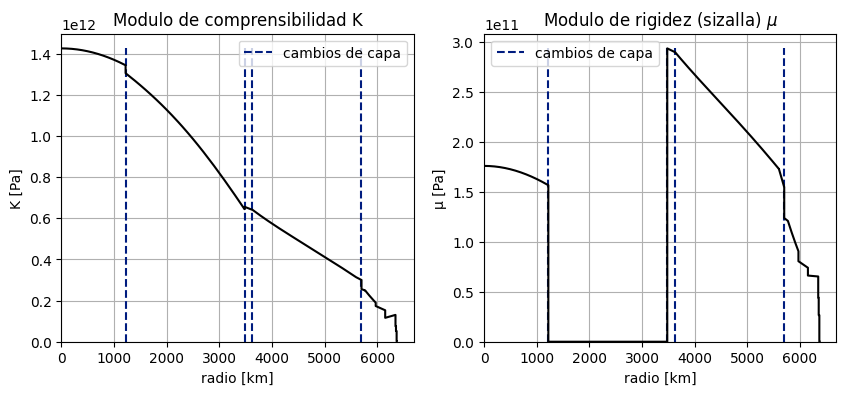


los cambios de capa se dan en: [1221.5 3480.  3630.  5701. ] [km]


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].set_title('Modulo de comprensibilidad K')
ax[0].vlines(r[i_min_dρ[:4]],0,max(K), linestyles='--',label='cambios de capa')
ax[0].set_xlabel("radio [km]")
ax[0].set_ylabel(r"K [Pa]")
ax[0].plot(r, K, 'k')
ax[0].set_ylim(0)
ax[0].set_xlim(0)
ax[0].legend()
ax[0].grid()

ax[1].set_title('Modulo de rigidez (sizalla) $\mu$')
ax[1].vlines(r[i_min_dρ[:4]],0,max(μ),linestyles='--',label='cambios de capa')
ax[1].set_xlabel("radio [km]")
ax[1].set_ylabel(r"μ [Pa]")
ax[1].plot(r, μ, 'k')
ax[1].set_ylim(0)
ax[1].set_xlim(0)
ax[1].legend()
ax[1].grid()
plt.show()
print(f'\nlos cambios de capa se dan en: {r[i_min_dρ][:4]} [km]')

### **2. Estimacion de parametros para los modelos de K y $μ$**

2. Vamos a encontrar una relación matemática general entre $K$ y $\mu$ como función de la densidad para el manto sólido de la Tierra y el núcleo líquido (solo el núcleo líquido). De acuerdo a modelos teóricos de medios continuos, los módulos se pueden escribir en general como:

   $$
   K(\rho) = a\rho^{n_K}\\
   \mu(\rho) = b\rho^{n_\mu}
   $$
   
   Hacer un ajuste de los parámetros $a, n_K, b, n_\mu$ para el manto y para el núcleo líquido. Escriba rutinas generales que permitan calcular $K$ y $\mu$ como función de la densidad.<br>

Como en este caso se desea ajustar los modulos en funcion de la densidad en lugar del radio, es necesario encontrar las densidades en las que se dan tales cambios, cuyos indices no coincidian exactamente con los de los indices de los radios, por lo que manualmente se ajustaron usando la grafica.

In [ ]:
# indices de cambio de capa en densidad
indx = [i_min_dρ[0]+1, i_min_dρ[1], i_min_dρ[1]-1, i_min_dρ[3]-1]

**Grafica de los modulos (K y $μ$) y su relacion con la densidad**

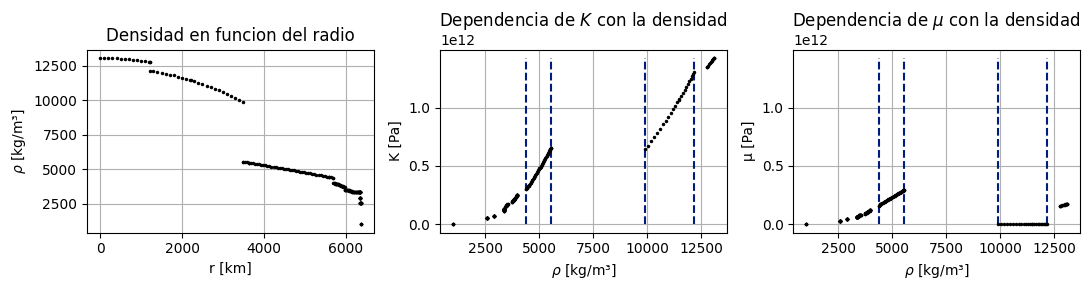

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
ax[0].set_title('Densidad en funcion del radio')
ax[0].plot(r, rho, 'k.', markersize=3)
ax[0].set_ylabel(r"$ρ$ [kg/m³]")
ax[0].set_xlabel("r [km]")
ax[0].grid()

ax[1].set_title('Dependencia de $K$ con la densidad')
ax[1].vlines(rho[indx], 0, max(K), linestyles='--')
ax[1].plot(rho, K,'k.', markersize=3)
ax[1].set_xlabel("$ρ$ [kg/m³]")
ax[1].set_ylabel(r"K [Pa]")
ax[1].grid()

ax[2].set_title('Dependencia de $μ$ con la densidad')
ax[2].vlines(rho[indx], 0, max(K), linestyles='--')
ax[2].plot(rho, μ,'k.', markersize=3)
ax[2].set_xlabel("$ρ$ [kg/m³]")
ax[2].set_ylabel(r"μ [Pa]")
ax[2].grid()
fig.tight_layout()

Los valores a ajustar seran los de $K$ y $μ$ del nucleo interno y del manto, los cuales se tomaran usando mascaras booleanas con los indices limite encontrados en las celdas anteriores. Note que el manto se encuentra al rededor de los $5000$ kg/m$^3$ de densidad, y el nucleo externo se encuentra aproximadamente entre de los $10$ mil kg/m$^3$ y $12$ mil kg/m$^3$

In [ ]:
# mascaras booleanas para las capas
bool_ne = (rho[indx[0]]>rho) & (rho>rho[indx[1]])
bool_ma = (rho[indx[2]]>rho) & (rho>rho[indx[3]])

# densidades por capa
rho_ne = rho[ bool_ne ]
rho_ma = rho[ bool_ma ]

# radios por capa
r_ne = r[ bool_ne ]
r_ma = r[ bool_ma ]

# modulos por capa
K_ne = K[ bool_ne ]
K_ma = K[ bool_ma ]
μ_ne = μ[ bool_ne ]
μ_ma = μ[ bool_ma ]

**Ajuste de parametros por `curvefit`:**

Curvefit recibe la funcion a la que se desea ajustar (que en este caso se definieron como potenciales en base a la densidad como $K(\rho) = a\rho^{n_K}$ y  $\mu(\rho) = b\rho^{n_\mu}$), los datos en $X$ y $Y$ respectivamente (en este caso serian la densidad en $X$ y en $Y$ los modulos), y retorna una lista con los parametros resultantes del ajuste y la matriz de covarianza de los parametros. Por otra parte, note que el valor de los exponentes debe ser adimensional, mientras que el parametro que escala ($a$ y $b$) deben tener unidades que concuerden con las de los modulos (Pa), y que dependen del valor del exponente de la densidad, siendo unidades de [kg$^{1-n}$/ (m$^{1-3n}$ s$^2$)]

* Documentacion de scipy.optimize.curve_fit. Recuperado de: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html

In [ ]:
# modelos potenciales de los modulos en funcion de densidad
def K_fun(rho, a, n):
  return a*rho**n

def mu_fun(rho, b, n):
  return b*rho**n

Aplicando el ajuste a las funciones y los datos:

In [ ]:
# ajuste de parametros (a,n_k) de K
[a_Kne, n_Kne], covK1 = curve_fit(K_fun, rho_ne, K_ne)
[a_Kma, n_Kma], covK2 = curve_fit(K_fun, rho_ma, K_ma)

# ajuste de parametros (b,n_μ) de μ
[b_μne, n_μne], covμ1 = curve_fit(mu_fun, rho_ne, μ_ne)
[b_μma, n_μma], covμ2 = curve_fit(mu_fun, rho_ma, μ_ma)

**Grafica del ajuste para el modulo $K$**



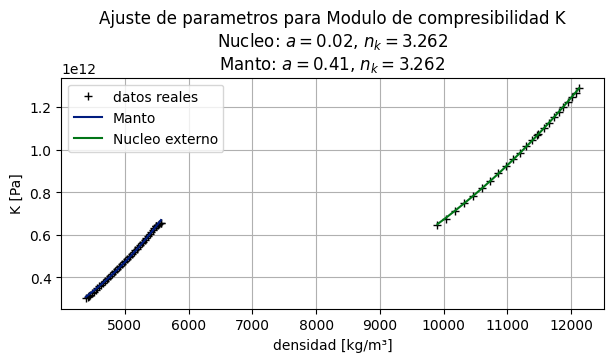


Error estandar en los parametros del Nucleo:
 Δa=0.0017, Δn=0.0091

Error estandar en los parametros del Manto:
 Δa=0.0694, Δn=0.0200


In [ ]:
fig = plt.figure(figsize=(7,3))
tex = f'Nucleo: $a=${a_Kne:.2}, $n_k=${n_Kma:.3f}\n'
tex += f'Manto: $a=${a_Kma:.2}, $n_k=${n_Kma:.3f}'
plt.title(f'Ajuste de parametros para Modulo de compresibilidad K\n'+tex)

# K manto
plt.plot(rho_ma, K_ma, 'k+', label='datos reales')
plt.plot(rho_ma, K_fun(rho_ma, a_Kma, n_Kma) , label='Manto')
# K nucleo externo
plt.plot(rho_ne, K_ne, 'k+')
plt.plot(rho_ne, K_fun(rho_ne, a_Kne, n_Kne), label='Nucleo externo')
plt.xlabel("densidad [kg/m³]")
plt.ylabel(r"K [Pa]")
plt.legend()
plt.grid()
plt.show()

# error estandar en los parametros
error_k1 = np.sqrt(np.diag(covK1))
error_k2 = np.sqrt(np.diag(covK2))
print(f'\nError estandar en los parametros del Nucleo:')
print(f' Δa={error_k1[0]:.4f}, Δn={error_k1[1]:.4f}')
print(f'\nError estandar en los parametros del Manto:')
print(f' Δa={error_k2[0]:.4f}, Δn={error_k2[1]:.4f}')

**Grafica del ajuste para el modulo $μ$**

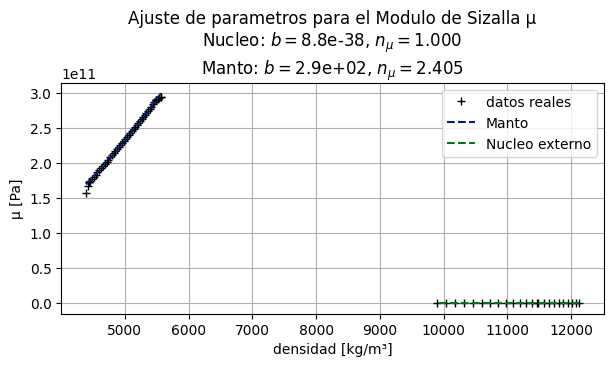


Error estandar en los parametros del Nucleo:
 Δb=3.0e-36, Δn=5.6e-09

Error estandar en los parametros del Manto:
 Δb=52.4423, Δn=0.0210


In [ ]:
fig = plt.figure(figsize=(7,3))
tex = f'Nucleo: $b=${b_μne:.2}, $n_μ=${n_μne:.3f}\n'
tex += f'Manto: $b=${b_μma:.2}, $n_μ=${n_μma:.3f}'
plt.title(f'Ajuste de parametros para el Modulo de Sizalla μ\n'+tex)

# μ manto
plt.plot(rho_ma, μ_ma, 'k+', label='datos reales')
plt.plot(rho_ma, mu_fun(rho_ma, b_μma, n_μma), '--', label='Manto')
# μ nucleo externo
plt.plot(rho_ne, μ_ne, 'k+')
plt.plot(rho_ne, mu_fun(rho_ne, b_μne, n_μne),'--', label='Nucleo externo')
plt.xlabel("densidad [kg/m³]")
plt.ylabel(r"μ [Pa]")
plt.legend()
plt.grid()
plt.show()

# error estandar en los parametros
error_μ1 = (np.diag(covμ1))**.5
error_μ2 = (np.diag(covμ2))**.5
print(f'\nError estandar en los parametros del Nucleo:')
print(f' Δb={error_μ1[0]:.1e}, Δn={error_μ1[1]:.1e}')
print(f'\nError estandar en los parametros del Manto:')
print(f' Δb={error_μ2[0]:.4f}, Δn={error_μ2[1]:.4f}')

### **3. Solucion del sistema de ecuaciones para Presion, Masa y densidad**

3. Vamos ahora a construir un planeta modelo en el cual podamos estudiar la propagación de ondas sísmicas. Este planeta tendrá la masa y asumiremos que tiene solo un núcleo líquido (como sugieren algunos modelos). Para ello resolveremos las ecuaciones:
  
  $$
  \begin{eqnarray}
  \frac{\mathrm d p}{\mathrm d r} & = & -\rho g\\
  \frac{\mathrm d M_r}{\mathrm d r} & = & 4\pi r^2\rho \\
  \frac{\mathrm d \rho}{\mathrm d r} & = & -\frac{\rho^2g}{K(\rho)}
  \end{eqnarray}
  $$
  donde $g=GM_r/r^2$ y $K(\rho)$ es la compresibilidad del material. Debe tenerse en cuenta cuando se escriba la rutina de estas ecuaciones que el cálculo de $K$ debe hacerse con los ajustes que obtuvimos en el punto 2. Para ello vamos a comenzar en la superficie del planeta con condiciones iniciales:
  
   $$p(R) = 0, M_r = M_m, \rho(R) = 3000$$
   
  donde $M_m$ es la masa de Marte y $R$ es el radio del planeta (puede comenzar suponiendo que el radio es 0.8 veces el radio del Marte real). Suponemos que el núcleo del planeta siempre esta siempre ubicado en $r_N = 0.5 R$.  Integre las ecuaciones hasta $r=r_N$. Usando la presión, la densidad y masa obtenidos por está integral, vamos ahora a integrar nuevamente las ecuaciones hasta muy cerca al centro (pe. $r = 0.1 r_N$). No podemos llegar hasta el centro mismo porque las ecuaciones son singulares allí. Es importante entender que al pasar del manto al núcleo, la densidad aumenta (por el cambio en la composición) en un factor de 1.7 (de silicatos a Hierro). Haga un gráfico de la densidad, masa y presión obtenida con esta integración.<br>

Definiendo las condiciones iniciales y las capas de este nuevo planeta en la siguiente celda, se empleó la funcion `solve_ivp` de `scipy.integrate` para resolver el sistema. En cuanto a notacion dentro del codigo; como en este caso se asume que el unico nucleo es liquido se denoto como **nu**, mientras el manto sigue denotado como **ma**.


* Documentacion de scipy.integrate.solve_ivp. Recuperado de: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html


In [ ]:
# Capas del planeta
r_planet = 0.8*R_mars     # radio [m]
r_N = 0.5*R_mars          # radio del nucleo [m]
r_singular = 0.1*r_N      # radio singular [m]

# Condiciones iniciales superficie
p_r0 = 0                  # [pa]
M_r0 = M_mars             # [kg]
rho_r0 = 3000             # [kg/m^3]
y0_1 = [p_r0, M_r0, rho_r0]

**Solucionando el sistema en el manto** :

Definiendo una funcion para el sistema del manto, y su respectivo arreglo de radios, se integró de la siguiente forma, donde la gravedad tiene la forma: $g=G M_r/r^2$, y el modulo de compresibilidad $K$ se tomó con la funcion de ajuste encontrada previamente con los parametros del manto.

In [ ]:
def system_ma(r, y):
    p, Mr, rho = y

    # sistema
    dp_dr = -rho * G*Mr/r**2 # presion
    dMr_dr = 4*np.pi*r**2 * rho # masa
    drho_dr = -rho**2*G*Mr / (K_fun(rho, a_Kma, n_Kma)*r**2) # densidad

    return [dp_dr, dMr_dr, drho_dr]

# solucionando en el manto
r_mant = np.linspace(r_planet, r_N, 1000) # radios
solution_ma = solve_ivp(system_ma, (r_planet, r_N), y0_1, t_eval=r_mant)
p_ma, Mr_ma, rho_ma = solution_ma.y

**Solucionando el sistema en el nucleo** :

Definiendo una segunda funcion para el sistema en el nucleo, junto con un arreglo de radios, se integró, esta vez con el ajuste del modulo de compresibilidad $K$ con los parametros del nucleo

In [ ]:
# Condiciones iniciales nucleo
y0_2 = [p_ma[-1], Mr_ma[-1], rho_ma[-1]*1.7]

def system_nu(r, y):
    p, Mr, rho = y

    # sistema
    dp_dr = -rho * G*Mr/r**2 # presion
    dMr_dr = 4*np.pi*r**2 * rho # masa
    drho_dr = -rho**2 * G * Mr / (K_fun(rho, a_Kne, n_Kne) * r**2) # densidad

    return [dp_dr, dMr_dr, drho_dr]

# solucionando en nucleo
r_nucleo = np.linspace(r_N, r_singular, 1000) # radios [m]
solution_nu = solve_ivp(system_nu, (r_N, r_singular), y0_2, t_eval=r_nucleo)
p_nu, Mr_nu, rho_nu = solution_nu.y

**Grafica de las variables encontradas de la solucion del sistema** :

Cada grafica tiene el eje $X$ (los radios) compartido

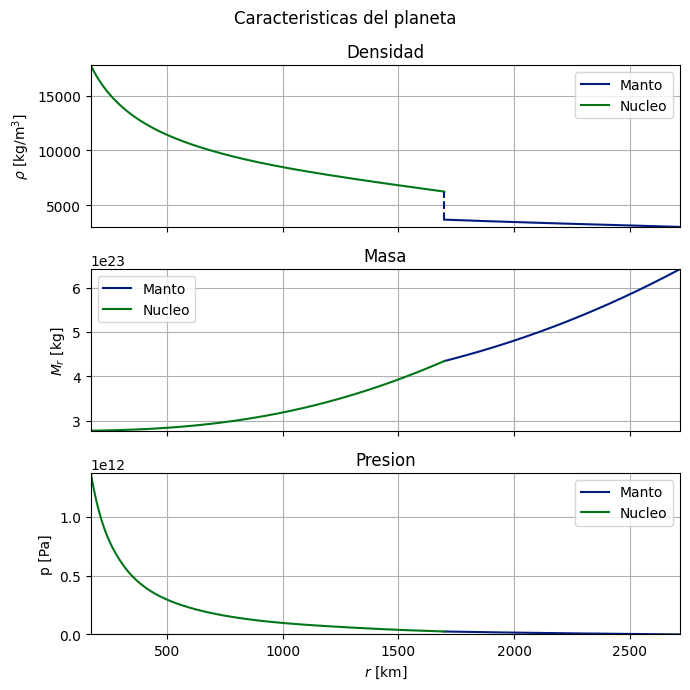

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(7,7),sharex=True)
fig.suptitle('Caracteristicas del planeta')

ax[0].set_title(r"Densidad")
ax[0].plot(r_mant/1e3, rho_ma, label="Manto")
ax[0].plot(r_nucleo/1e3, rho_nu, label="Nucleo")
ax[0].vlines(r_mant[-1]/1e3, rho_ma[-1], rho_nu[0], linestyle='--')
ax[0].set_ylabel(r"$\rho$ [kg/m$^3$]")
ax[0].margins(0)
ax[0].legend()
ax[0].grid()

ax[1].set_title(r"Masa")
ax[1].plot(r_mant/1e3, Mr_ma, label="Manto")
ax[1].plot(r_nucleo/1e3, Mr_nu, label="Nucleo")
ax[1].set_ylabel(r"$M_r$ [kg]")
ax[1].margins(0)
ax[1].legend()
ax[1].grid()

ax[2].set_title(r"Presion")
ax[2].plot(r_mant/1e3, p_ma, label="Manto")
ax[2].plot(r_nucleo/1e3, p_nu, label="Nucleo")
ax[2].set_ylabel(r"p [Pa]")
ax[2].set_xlabel(r"$r$ [km]")
ax[2].margins(0)
ax[2].legend()
ax[2].grid()
fig.tight_layout()

### **4. Overshooting Planerario**


4. Cuando se hace esta última integración, es posible que en el centro obtenga un valor positivo de $M_r/M_m$ que no tiene sentido. Muy cerca al centro se debe cumplir que $M_r/M_m\approx 0$. Para que se consiga esta situación debe aumentarse el radio: $R=0.8R_m$, $R=0.9R_m$, $R=R_m$, $R=1.01R_m$, etc. Observe como el valor de $M_r/M_m$ en el centro va disminuyendo. Si sigue aumentando el radio en un momento dado $M_r/M_m$ se hace negativo, lo que tampoco tiene sentido. Encuentre el radio del cuerpo tal que $M_r/M_m$ sea lo más pequeño posible. Una vez encontrado ese será el radio real del planeta. A este método se lo conoce como *overshooting* y es muy utilizado en el estudio del interior de planetas y estrellas. Una vez obtenida las propiedades del planeta cálcule y grafique en función del radio: $M_r$, g, presión, densidad, K, $\mu$, $v_s$ y $v_P$.<br>

Verificando la razon de la ultima masa calculada del sistema anterior con respecto a la masa total del planeta, no es exactamente cero:


In [ ]:
# razon ultima masa-masa total
Mr_nu[-1]/M_mars

0.4321002504805806

**Solucion del sistema para muchos radios** :

Para encontrar el radio optimo en el cual tal razon sea una aproximacion a cero, se creó un arreglo con varios radios posibles para el planeta, con un paso de $1e^{-4}$ entre cada uno, y se repitió el proceso de solucion del sistema dentro de un ciclo for; con una condicion de parada justo donde la razon de masas se vuelva negativa, de modo que se pueda tomar el radio anterior a este caso, que seria el radio optimo por overshoooting.

In [ ]:
# radios a estudiar
rs = np.arange(0.8, 1.5, 1e-4)*R_mars # [m]
ratio_mass = [] # razon de masas
sols_ma = [] # soluciones del manto
sols_nu = [] # soluciones del nucleo

for ri in tqdm(rs):

  # Capas del planeta
  r_planet = 0.8*ri     # radio del planeta [m]
  r_N = 0.5*ri          # radio del nucleo [m]
  r_singular = 0.1*r_N  # radio singular [m]

  # solucionando manto
  y0_1 = [0, M_mars, 3000] # ICS 1
  r_ma = np.linspace(r_planet, r_N, 1000)
  p_ma, Mr_ma, rho_ma = solve_ivp(system_ma, (r_planet, r_N),
                                  y0_1, t_eval=r_ma).y

  # solucionando nucleo
  y0_2 = [p_ma[-1], Mr_ma[-1], rho_ma[-1]*1.7] # ICS 2
  r_nu = np.linspace(r_N, r_singular, 1000)
  p_nu, Mr_nu, rho_nu = solve_ivp(system_nu, (r_N, r_singular),
                                  y0_2, t_eval=r_nu).y

   # condicion de parada y guardando datos
  if Mr_nu[-1]/M_mars < 0: break
  ratio_mass.append(Mr_nu[-1]/M_mars)
  sols_ma.append([p_ma, Mr_ma, rho_ma, r_ma])
  sols_nu.append([p_nu, Mr_nu, rho_nu, r_nu])

ratio_mass = np.array(ratio_mass)
solution_nu = np.array(sols_nu)
solution_ma = np.array(sols_ma)

 64%|██████▍   | 4463/7000 [00:37<00:21, 119.88it/s]


**Radio del planeta encontrado por Overshooting** :

Este radio de overshooting es el asociado a la ultima razon de masa guardada en el ciclo anterior.

In [ ]:
mass_aprox = ratio_mass[-1]    # razon masa final-total
r_over = rs[ len(ratio_mass) ] # radio de overshooting

print(f'Para el radio: {r_over/1e3:.2f}[km] = {r_over/R_mars:.2f} radios marte')
print(f'la razon masa final/total es: {mass_aprox:.5f} ')

Para el radio: 4232.67[km] = 1.25 radios marte
la razon masa final/total es: 0.00016 


Ya se tiene los datos de la densidad, masa y presion para el radio optimo del planeta, ahora se calcularan las demas variables asociadas a estas soluciones; Los modulos de Compresibilidad y Sizalla se encontraran usando las funciones de ajuste encontradas con los valores de la tierra en los puntos anteriores. La gravedad se encontró usando la misma forma empleada dentro del sistema de euaciones diferenciales anterior, y finalmente para las velocidades de las ondas P y S, se usaron las relaciones de sismologia con la densidad y los modulos de compresibilidad y sizalla.

**Para la Gravedad**:
$$ g = G \ M_r/r^2 $$

**Velocidad de ondas secundarias**:
$$ v_s = \sqrt{μ/ρ}$$

**Velocidad de ondas primarias**:
$$ v_p = \sqrt{\frac{K+4μ/3}{ρ}}$$




El calculo de estos valores se realizó con los metodos nativos de python `list` y `map`, poderosos pero que ignoraba, lo cuales permiten evaluar listas directamente en funciones, sin necesidad de convertir las listas en arreglos de `numpy`.

* Python map() Function Guide (With Examples). Recuperado de: [https://ioflood.com/blog/python-map/](https://ioflood.com/blog/python-map/#:~:text=The%20map%20function%20in%20Python%20applies%20a%20given%20function%20to,a%20list%20of%20the%20results.&text=In%20this%20example%2C%20the%20map,returns%20the%20square%20of%20x%20.)




In [ ]:
# soluciones asociadas al overshooting
p_ma, Mr_ma, ρ_ma, rs_ma = solution_ma[-1,:,:]
p_nu, Mr_nu, ρ_nu, rs_nu = solution_nu[-1,:,:]

# calculo de los demas valores
K_over = list(map(K_fun, [ρ_ma, ρ_nu], [a_Kma, a_Kne], [n_Kma, n_Kne]))
μ_over = list(map(mu_fun, [ρ_ma, ρ_nu], [b_μma, b_μne], [n_μma, n_μne]))
g_over = list(map(lambda m,r: G*m/r**2, [Mr_ma, Mr_nu], [rs_ma, rs_nu]))
vS_over= list(map(lambda μ,ρ: (μ/ρ)**.5, μ_over, [ρ_ma, ρ_nu] ))
vP_over= list(map(lambda K,μ,ρ:((K+4*μ/3)/ρ)**.5, K_over, μ_over, [ρ_ma,ρ_nu]))

**Grafica de todas las caracteristicas del planeta mediante Overshooting**

Graficando todos los datos encontrados mediante el proceso de overshooting planetario:

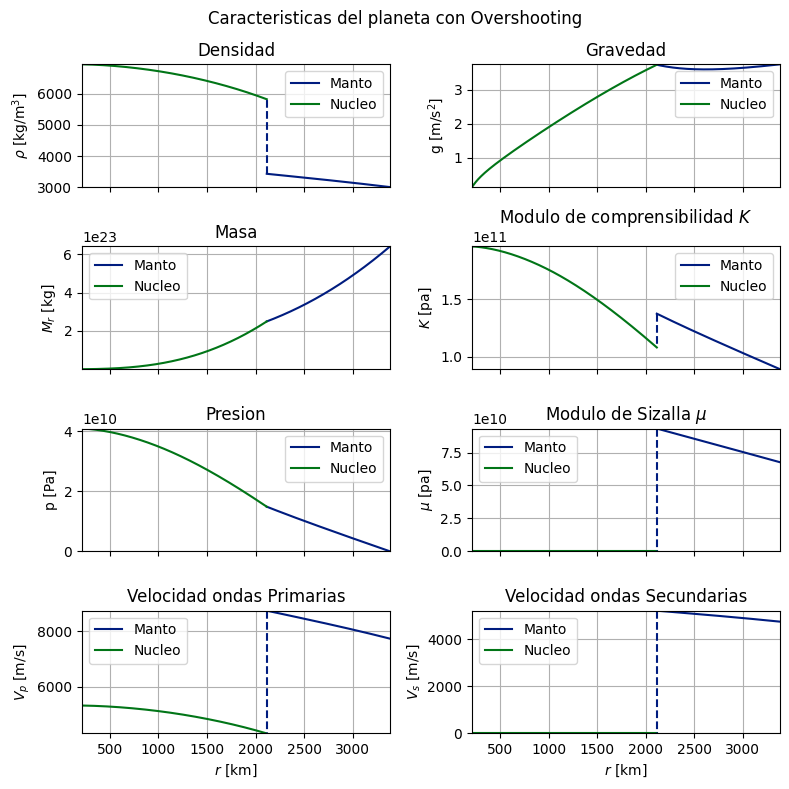

In [ ]:
fig, ax = plt.subplots(4,2, figsize=(8,8),sharex=True)
fig.suptitle('Caracteristicas del planeta con Overshooting')

ax[0,0].set_title("Densidad")
ax[0,0].plot(rs_ma/1e3, ρ_ma, label="Manto")
ax[0,0].plot(rs_nu/1e3, ρ_nu, label="Nucleo")
ax[0,0].vlines(rs_ma[-1]/1e3, ρ_ma[-1], ρ_nu[0], linestyle='--')
ax[0,0].set_ylabel(r"$ρ$ [kg/m$^3$]")

ax[1,0].set_title("Masa")
ax[1,0].plot(rs_ma/1e3, Mr_ma, label="Manto")
ax[1,0].plot(rs_nu/1e3, Mr_nu, label="Nucleo")
ax[1,0].set_ylabel(r"$M_r$ [kg]")

ax[2,0].set_title("Presion")
ax[2,0].plot(rs_ma/1e3, p_ma, label="Manto")
ax[2,0].plot(rs_nu/1e3, p_nu, label="Nucleo")
ax[2,0].set_ylabel(r"p [Pa]")

ax[0,1].set_title("Gravedad")
ax[0,1].plot(rs_ma/1e3, g_over[0], label="Manto")
ax[0,1].plot(rs_nu/1e3, g_over[1], label="Nucleo")
ax[0,1].set_ylabel(r"g [m/s$^2$]")

ax[1,1].set_title(r"Modulo de comprensibilidad $K$")
ax[1,1].plot(rs_ma/1e3, K_over[0], label="Manto")
ax[1,1].plot(rs_nu/1e3, K_over[1], label="Nucleo")
ax[1,1].vlines(rs_ma[-1]/1e3, K_over[0][-1], K_over[1][0], linestyle='--')
ax[1,1].set_ylabel(r"$K$ [pa]")

ax[2,1].set_title(r"Modulo de Sizalla $μ$")
ax[2,1].plot(rs_ma/1e3, μ_over[0], label="Manto")
ax[2,1].plot(rs_nu/1e3, μ_over[1], label="Nucleo")
ax[2,1].vlines(rs_ma[-1]/1e3, μ_over[0][-1], μ_over[1][0], linestyle='--')
ax[2,1].set_ylabel(r"$μ$ [pa]")

ax[3,0].set_title("Velocidad ondas Primarias")
ax[3,0].plot(rs_ma/1e3, vP_over[0], label="Manto")
ax[3,0].plot(rs_nu/1e3, vP_over[1], label="Nucleo")
ax[3,0].vlines(rs_ma[-1]/1e3, vP_over[0][-1], vP_over[1][0], linestyle='--')
ax[3,0].set_ylabel(r"$V_p$ [m/s]")
ax[3,0].set_xlabel(r"$r$ [km]")

ax[3,1].set_title("Velocidad ondas Secundarias")
ax[3,1].plot(rs_ma/1e3, vS_over[0], label="Manto")
ax[3,1].plot(rs_nu/1e3, vS_over[1], label="Nucleo")
ax[3,1].vlines(rs_ma[-1]/1e3, vS_over[0][-1], vS_over[1][0], linestyle='--')
ax[3,1].set_ylabel(r"$V_s$ [m/s]")
ax[3,1].set_xlabel(r"$r$ [km]")

for i in range(4):
  for j in range(2):
    ax[i,j].margins(0)
    ax[i,j].legend()
    ax[i,j].grid()
fig.tight_layout()

la velocidad de las ondas S es practicamente nula en el nucleo debido a que se usó el ajuste del nucleo externo liquido de la tierra, pues el modulo de sizalla en medios liquidos se hace cero, debido a que ante esferzos de corte los fluidos presentan movimiento y no rigidez. Algo similar se observa para las ondas primarias, pero como estan relacionadas con la compresibilidad, los fluidos si la presentan, y su valor no es nulo, sino que se presenta como una disminucion en la velocidad al pasar de medio solido a liquido.


<br><br><br>

____

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - Gráficos de cada punto.

- Datos mínimos:
  - Los números solicitados en cada punto.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.


5. **(Opcional)** Usando el modelo resultante, vamos a estudiar la propagación de ondas sísmicas en el interior del planeta. Para ello usaremos un modelo 2D (el planeta como un círculo).

  Vamos a producir un rayo de ondas P en el polo norte del planeta y veremos como se propagan por el interior. Este rayo debe salir no en dirección vertical hacia abajo, sino formando un ángulo con la vertical.
  
  Dividamos el planeta en 50 capas concéntricas en el manto y 50 en el núcleo.
  Propague el rayo hasta la primera capa interior a partir de la superficie. Calcule el ángulo de incidencia en el punto en el que el rayo llega a esa capa y la velocidad de las ondas P allí. Usando la ley de Snell calcule el ángulo de refracción y vuelva a propagar el rayo hasta la siguiente capa y así sucesuvamente.

  Repita lo anterior hasta que la onda llegue al otro lado del planeta. Ahora bien, si en una capa dada, el ángulo de incidencia es casi 90 grados (incidencia rasante) en lugar de refractar el rayo, suponga que se refleja. Repita la propagación hasta que el rayo alcance la superficie. Como nunca será 90 grados, suponga que la reflexión ocurre cuando el ángulo de incidencia es 80 grados. Puede variar esta condición para obtener mejores resultados.

  Repita el mismo procedimiento con rayos en muchas direcciones diferentes y gráfique el camino de los rayos en el interior del planeta.

  Haga lo mismo pero con las ondas S (tenga en cuenta que si el rayo S llega al núcleo sólido no puede continuar).